# ⚙️GEAR: General Evaluation for Abductive Reasoning

This repository accompanies our paper **GEAR** (General Evaluation for Abductive Reasoning).  
GEAR provides a **fully automated, label-free, and scalable framework** to evaluate abductive reasoning in large language models.  
It measures hypothesis sets along three classical dimensions:

- **Consistency** – hypotheses must correctly explain given observations  
- **Generalizability** – consistent hypotheses should make testable predictions on unseen inputs  
- **Diversity** – hypothesis sets should cover distinct perspectives and non-redundant patterns  

We benchmarked 9 LLMs on 4 popular datasets (MINI-ARC, ACRE, LIST FUNCTIONS, ARC-2025), generating over 50k hypotheses.
We also propose a **momentum-based curriculum training strategy** that improves all three objectives without gold-label supervision

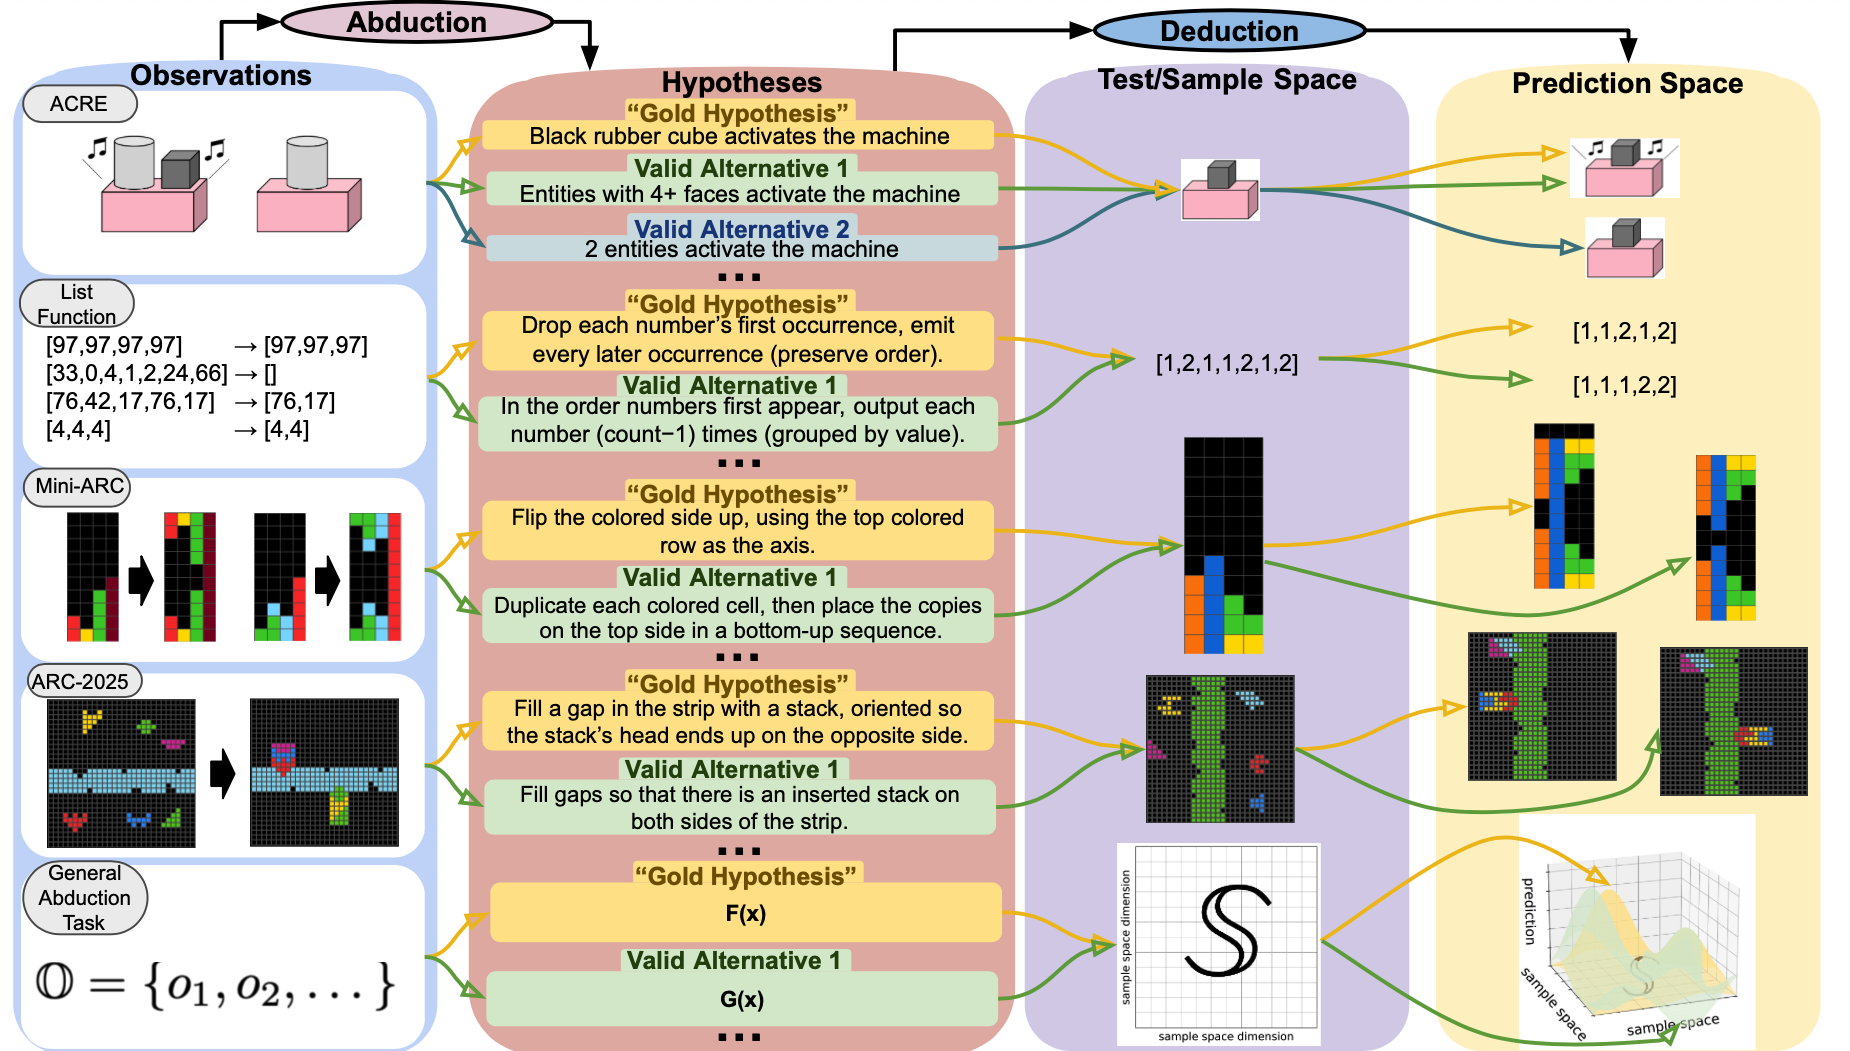

# $\textcolor{purple}{\text{GEAR evaluation on 9 LLMs}}$

### Step 1, Generate initial observation(io) pairs (See in paper section 4 Sampling initial observations.)
- Call `python generate_io_pairs.py` to sample the initial observations to seed abduction.
- We have random sampled io paris form 4 dataset saved in ../data/io_pairs
- However if you want to generate new io_pairs with your random seed you can use function `utils.load_io_pairs_{dataset_name}`

In [1]:
import utils
for n in range(1,5): # random io count from 1~4
    init_io_count_list_function = utils.load_io_pairs_list_function(n, seed = 42)
list(init_io_count_list_function.items())[:3]

[(163,
  [('[27, 33, 10]', '[11, 13, 7]'),
   ('[1, 6, 83, 99, 41, 30]', '[5, 6, 25, 29, 15, 12]'),
   ('[14, 72, 2, 89, 97, 7, 6]', '[8, 23, 5, 27, 29, 6, 6]'),
   ('[52, 65, 67, 8, 54, 85]', '[18, 21, 21, 7, 18, 26]')]),
 (28,
  [('[3, 9, 7, 5, 4, 0, 2, 6]', '[7, 5, 4, 0, 2, 6]'),
   ('[0, 1, 9, 4, 2, 3, 5]', '[9, 4, 2, 3, 5]'),
   ('[4, 6, 0, 8, 9, 7, 5, 3]', '[0, 8, 9, 7, 5, 3]'),
   ('[8, 6, 2]', '[2]')]),
 (6,
  [('[8, 1, 4, 9]', '[8, 1]'),
   ('[0, 2, 7, 4, 5, 9, 3, 1, 8]', '[0, 2]'),
   ('[6, 8, 3, 2, 9, 4, 5, 1]', '[6, 8]'),
   ('[7, 4, 3, 9, 2, 8, 5, 0, 1, 6]', '[7, 4]')])]

### step 2 generate hypothesis
- For generating hypothesis with 'o1' use the following command. (You can define new models and their name in  `global_variables.py` and **make sure to provide your api key and huggingface key**)
    - `python final_generate_hypothesis.py -m o1, -g 0,1,2,3,4` (Change the model name based on your definition in `global_variables.py`)
    - It saves while generating, if it stops, recall the same command.

### Step 3 generate prediction space
- After step 2, you need to generate corresponding prediction space for each generated hypothesis.
- Use the following command to generate prediction space and save them.
    - `python final_generate_all_mappings.py -m o1` 

### Step 4 evaluate
- After all prediction space is generated you can call the following to evaluate
    - `python final_evaluate.py -m o1`

### Downloadable Content

We provide generated **hypotheses** and **preference data** used in our paper, so you can skip earlier steps if you don't want to generate from scratch.

1. Download the archive from **[Google Drive](https://drive.google.com/file/d/126DPVwlWdnPzNT2zQFJTtsUk3KjQwuk-/view?usp=sharing)**.
2. **Extract** the archive; you will see two folders: `generate_log/` and `training_data/`.
3. **Move** both folders into the project root (e.g., `Project_abduction_evaluation/`), so the structure looks like:
- Project_abduction_evaluation/
    - generate_log/
    - training_data/
4. Proceed directly to **Step 3**.

# $\textcolor{purple}{\text{Preference data generation}}$
- Both RL training and similation study rely on the pre-generated preference data.
- Call `python final_rl_data_gen.py` to generate preference data based on all LLM hypothesis you've generated.

# $\textcolor{purple}{\text{Simulation study}}$

### Simulation Study 1 (See in paper section 5.2)
- `python final_simulation_study_defeasible.py -tc 1 -tr 5` (tc: how many test cases you want to use, tr: how many round do you willing to run this experiment)
- Since MINI-ARC and ARC-2025 do not provide enough observations in our experiment $tc \leq 4$

### Simulation Study 2 (See in paper section 5.3)
- `python final_simulation_study_general.py -tc 1 -tr 5`

# $\textcolor{purple}{\text{Train, validation, held out split}}$
- We provide the train/validation/held-out split in `training_data`. You may also use your own split. The format is simple: for each dataset, list the problem IDs assigned to train, validation, and held-out sets.

In [2]:
import json
with open('training_data/dpo_train_ids.json', 'r') as f:
    train_split = json.load(f)
print(train_split['acre'])
# shown is the train ids for ACRE dataset

['0', '12', '13', '14', '17', '18', '2', '21', '22', '27', '3', '32', '38', '39', '4', '40', '41', '42', '44', '49', '5', '51', '52', '53', '59', '6', '81', '83', '84', '85', '87', '89', '93', '95', '98', '69', '72', '74', '77', '80']


# $\textcolor{purple}{\text{Reinforcement Learning and Evaluation}}$

### Step 1: Model training:
- Call ```python final_dpo_default_curriculum -m llama-3.1-8b -g 0 -p example_train -t scratch``` where
    -  -m: is the model name you provided in the global_variables.py
    -  -g: is the gpu you want to use 0,2,3 means you want to use GPU 0, 2 and 3 (in our experiment we use single A100 80G GPU)
    -  -p: is the postfix of the save_dir of the check point
    -  -t: don't need to change this.

### Step2: Generate hypothesis on held out problems and generate prediction space
- Call `python final_generate_hypothesis_auto_save_mappings_t3.py -m model_name -g 0 -r 5` where
-  -m is the model name you specified in global_variables.py
-  -g is the gpu you want to use for generation
-  -r stands for how many round do you want to run the evaluation
-  The scrip saves while running, you can rerun the same command if it stopps.

### Step3: Evaluate
- Call `python final_evaluate_t3 -m model_name -r 5` where
-  -m is the model name you specified in global_variables.py
-  -r stands for how many round of hypothesis and prediction space you previously generated

# $\textcolor{purple}{\text{Ablation study}}$

- Call `python final_dpo_default_simple_single_preference.py -m model_name -g 0 -p example_train -t scratch -pr parsing` where
    - -m: is the base model you want to train
    - -g: is the gpu you want to use
    - -p: is the postfix of the save_dir
    - -t: don't need to change this.
    - -pr: is the single preference type you want to train
- Then same to previous experiment run `final_generate_hypothesis_auto_save_mappings_t3.py` and `python final_evaluate_t3` for evaluation

# $\textcolor{purple}{\text{Final Results}}$

In [3]:
import re
import json
import os
import utils
import copy
import numpy as np
import ast
from global_variables import *
import example_utils
from collections import OrderedDict
import generate_utils
import pandas as pd
with open('training_data/held_out_ids_t3.json', 'r') as f:
    t3_held_out = json.load(f)

held_out_problem_id = t3_held_out
datasets = {}
for dataset_name in held_out_problem_id.keys():
    if dataset_name == 'arc_2025':
        cur_dataset = utils.load_arc_2025_dataset()
    else:
        cur_dataset = utils.load_other_dataset(dataset_name)
    # do filter
    cur_dataset = {item[0]:item[1] for item in cur_dataset.items() if item[0] in held_out_problem_id[dataset_name]}
    datasets.update({
        dataset_name:cur_dataset
    })

llama_groups = {
    'Llama-3.1-8b': [
        ('llama-3.1-8b',None,'',1),('llama-3.1-8b',None,'',2),('llama-3.1-8b',None,'',3),('llama-3.1-8b',None,'',4),('llama-3.1-8b',None,'',5)
    ],
    'Llama-3.1-8b-dpo-fixed-ratio': [
        ("llama-fix",None,'',1),("llama-fix",None,'',2),("llama-fix",None,'',3),("llama-fix",None,'',4),("llama-fix",None,'',5)
    ],
    'Llama-3.1-8b-dpo-momentum-curriulum': [
        ("llama-momentum",None,'',1),("llama-momentum",None,'',2),("llama-momentum",None,'',3),("llama-momentum",None,'',4),("llama-momentum",None,'',5)
    ],
}
qwen_groups = {
    'qwen-2.5-7b': [
        ('qwen2.5-7b',None,'',1),('qwen2.5-7b',None,'',2),('qwen2.5-7b',None,'',3),('qwen2.5-7b',None,'',4),('qwen2.5-7b',None,'',5)
    ],
    'qwen-2.5-7b-dpo-fixed-ratio': [
        ('qwen-fix',None,'',1),('qwen-fix',None,'',2),('qwen-fix',None,'',3),('qwen-fix',None,'',4),('qwen-fix',None,'',5)
    ],
    'qwen-2.5-7b-dpo-momentum-curriulum': [
        ("qwen-momentum",None,'',1),("qwen-momentum",None,'',2),("qwen-momentum",None,'',3),("qwen-momentum",None,'',4),("qwen-momentum",None,'',5)
    ],
}
nextcoder_groups = {
    'nextcoder-7b': [
        ('mic-coder-7b',None,'',1),('mic-coder-7b',None,'',2),('mic-coder-7b',None,'',3),('mic-coder-7b',None,'',4),('mic-coder-7b',None,'',5)
    ],
    'nextcoder-7b-dpo-fixed-ratio': [
        ("nextcoder-fix",None,'',1),("nextcoder-fix",None,'',2),("nextcoder-fix",None,'',3),("nextcoder-fix",None,'',4),("nextcoder-fix",None,'',5)
    ],
    'nextcoder-7b-momentum-curriulum': [
        ('nextcoder-momentum',None,'',1),('nextcoder-momentum',None,'',2),('nextcoder-momentum',None,'',3),('nextcoder-momentum',None,'',4),('nextcoder-momentum',None,'',5)
    ],
}


postfix_mapping_dict = {
    "parsing-ablation":["llama-ablation-parsing","llama-ablation-consistent","llama-ablation-fair"],
    "consistent-ablation":["qwen-ablation-parsing","qwen-ablation-consistent","qwen-ablation-fair"],
    "fair-ablation":["nextcoder-ablation-parsing","nextcoder-ablation-consistent","nextcoder-ablation-fair"]
}

for model_index, (model_name,mapping_grounp) in enumerate(zip(['Llama-3.1-8b','qwem-2.5-7b','nextcoder-7b'],(llama_groups, qwen_groups, nextcoder_groups))):
    for postfix in postfix_mapping_dict:
        adaptor_index = postfix_mapping_dict[postfix][model_index]
        
        mapping_grounp.update({
            f'{model_name}-{postfix}':[(adaptor_index,None,'',i) for i in range(1,6)]
        })
    

grouped_cfgs = OrderedDict({
    **llama_groups,
    **qwen_groups,
    **nextcoder_groups,
})


multi_model_data, group_map_eval, group_order = example_utils._load_eval_data_for_named_groups(grouped_cfgs)

div_group_df = example_utils.generate_performance_table_t3_v2(
    multi_model_data,
    dataset_name='all',
    held_out_map=held_out_problem_id, 
    subset='held_out',             
    group_map=group_map_eval,  
)

div_group_df.index = [f'[{g}] (Agg)' for g in div_group_df.index]


final_results, group_map_res, group_order_res = example_utils._load_results_for_named_groups(grouped_cfgs)

pass_df_all = example_utils.generate_passrate_table_v3(
    final_results,
    dataset_name='all'
)
pass_df_with_agg = example_utils.append_group_summaries_passrate(
    pass_df_all,
    group_map=group_map_res,
    group_order=group_order_res,
    summary_suffix="(Agg)"
)

agg_index = [f'[{label}] (Agg)' for label in group_order_res]  
pass_group_df = pass_df_with_agg.loc[agg_index]

final_agg_only = div_group_df.join(pass_group_df, how='outer').loc[agg_index].round(4)

from IPython.display import display
display(final_agg_only)
final_agg_only.to_csv('named_groups_all_metrics_AGG_ONLY_9rows.csv')

import pandas as pd
import numpy as np

div_group_df.index = [f'[{g}] (Agg)' for g in div_group_df.index]


keep_cols_map = {
    'Instruction Following': 'Instruction Following Rate',
    'Consistency': 'Consistency',
    'Generalizability (Valid)': 'Generalizability',
    'Beta Struct Diversity (Valid)': 'Beta Diversity',
    'Normalized Gamma Diversity (Valid, q=0)': 'Gamma Diversity',
    'Avg Train Pass Rate': 'Avg Train Pass Rate',
    'Avg Test Pass Rate': 'Avg Test Pass Rate',
    'Top1 Accuracy': 'Top-1 Accuracy',
    'Top2 Accuracy': 'Top-2 Accuracy',
    'Top3 Accuracy': 'Top-3 Accuracy',
}

latex_split = example_utils.make_split_agg_latex(
    final_agg_only=final_agg_only,
    grouped_cfgs=grouped_cfgs,
    caption='Aggregated results across nine settings (group averages only).',
    label='tab:agg_9rows_split',
    as_percent=False,
    decimals=3,
    cross_column=False,           
    strip_brackets_in_index=True, 
    div_block_title='Diversity block',
    acc_block_title='T3 accuracy block'
)
print(latex_split)
# Some of the LLMs generated hypothesis may print something out during execution

Loading data from meta-llama/Llama-3.1-8B-Instruct_round1
Loading data from meta-llama/Llama-3.1-8B-Instruct_round2
Loading data from meta-llama/Llama-3.1-8B-Instruct_round3
Loading data from meta-llama/Llama-3.1-8B-Instruct_round4
Loading data from meta-llama/Llama-3.1-8B-Instruct_round5
Loading data from meta-llama/Llama-3.1-8B-Instruct_dpo_lora_128_256_0.5_simple_fixed_long_new_1_round1
Loading data from meta-llama/Llama-3.1-8B-Instruct_dpo_lora_128_256_0.5_simple_fixed_long_new_1_round2
Loading data from meta-llama/Llama-3.1-8B-Instruct_dpo_lora_128_256_0.5_simple_fixed_long_new_1_round3
Loading data from meta-llama/Llama-3.1-8B-Instruct_dpo_lora_128_256_0.5_simple_fixed_long_new_1_round4
Loading data from meta-llama/Llama-3.1-8B-Instruct_dpo_lora_128_256_0.5_simple_fixed_long_new_1_round5
Loading data from meta-llama/Llama-3.1-8B-Instruct_dpo_lora_128_256_0.5_momentum_long_frequent_momentum_round1
Loading data from meta-llama/Llama-3.1-8B-Instruct_dpo_lora_128_256_0.5_momentum_lon

<ast_guarded>:7: SyntaxWarning: 'generator' object is not subscriptable; perhaps you missed a comma?


0 0 5 0 0 0 6 0 3 0 0 0 3 0 0 0 0 8 0 6 0 8 0 0 0 
0 7 0 0 0 0 9 0 0 0 9 0 0 7 2 0 0 3 0 0 0 0 0 3 0 
0 0 5 0 3 0 4 0 0 0 0 0 0 0 4 8 0 3 0 0 0 0 0 8 0 
0 5 0 0 0 0 0 7 4 0 0 0 7 0 0 1 0 0 4 0 0 0 1 0 0 
0 0 0 3 0 0 6 0 0 7 7 0 6 0 0 0 0 1 1 3 0 0 0 0 0 
0 0 9 7 0 0 0 0 0 9 3 4 7 0 0 0 0 0 4 0 0 3 0 0 0 


<unknown>:3: SyntaxWarning: invalid decimal literal
<unknown>:3: SyntaxWarning: invalid decimal literal
<unknown>:4: SyntaxWarning: invalid decimal literal
<unknown>:2: SyntaxWarning: invalid decimal literal
<unknown>:2: SyntaxWarning: invalid decimal literal
<unknown>:2: SyntaxWarning: invalid decimal literal
<unknown>:2: SyntaxWarning: invalid decimal literal
<unknown>:2: SyntaxWarning: invalid decimal literal
<unknown>:2: SyntaxWarning: invalid decimal literal
<unknown>:2: SyntaxWarning: invalid decimal literal
<unknown>:2: SyntaxWarning: invalid decimal literal
<unknown>:2: SyntaxWarning: invalid decimal literal
<unknown>:2: SyntaxWarning: invalid decimal literal
<unknown>:2: SyntaxWarning: invalid decimal literal
<unknown>:3: SyntaxWarning: invalid decimal literal
<unknown>:2: SyntaxWarning: invalid decimal literal
<unknown>:6: SyntaxWarning: invalid decimal literal


-1
-1
-1
-1
3
3
-1
-1
-1
-1
-1
-1
-1
3
3
4
4
-1
-1
-1
-1
-1
-1
-1
3
5
5
-1
-1
-1
-1
-1
-1
4
2
4
-1
-1
-1
-1
-1
-1
-1
4
4
5
-1
-1
-1
-1
--- Generating Pass-Rate Table for dataset='all' ---


,Instruction Following,Consistency,"Normalized Gamma Diversity (Valid, q=0)",Beta Struct Diversity (Valid),Generalizability (Valid),Hypotheses Generated (Valid),Avg Train Pass Rate,Avg Test Pass Rate,Top1 Accuracy,Top2 Accuracy,Top3 Accuracy,#Hypotheses,#Follow,#Non-Follow,Follow Rate,#Inconsistent,#Consistent,Inconsistent Rate
[Llama-3.1-8b] (Agg),0.1488,0.0021,1.0000,0.0000,1.0000,1.0,0.0115,0.0089,0.0,0.0025,0.0037,2400,357,2043,0.1488,352,5,0.9877
[Llama-3.1-8b-dpo-fixed-ratio] (Agg),0.9679,0.0142,1.0000,0.0000,1.0000,6.6,0.0963,0.0761,0.0275,0.0425,0.0487,2400,2323,77,0.9679,2290,33,0.9858
[Llama-3.1-8b-dpo-momentum-curriulum] (Agg),0.9700,0.0204,1.1795,0.1959,1.0000,9.8,0.1285,0.1005,0.035,0.0525,0.065,2400,2328,72,0.97,2279,49,0.9789
[Llama-3.1-8b-parsing-ablation] (Agg),0.9412,0.0092,1.0000,0.0000,1.0000,4.4,0.1295,0.0986,0.0263,0.0312,0.0412,2400,2259,141,0.9412,2237,22,0.9903
[Llama-3.1-8b-consistent-ablation] (Agg),0.9962,0.0321,1.0077,0.0138,1.0000,15.4,0.1979,0.1537,0.045,0.055,0.0662,2400,2391,9,0.9963,2314,77,0.9678
[Llama-3.1-8b-fair-ablation] (Agg),0.9917,0.0196,1.1403,0.2217,1.0000,9.4,0.162,0.1251,0.045,0.055,0.0625,2400,2380,20,0.9917,2333,47,0.9802
[qwen-2.5-7b] (Agg),0.9883,0.0371,1.0014,0.0318,0.9869,17.8,0.1982,0.1543,0.035,0.0588,0.0675,2400,2372,28,0.9883,2283,89,0.9625
[qwen-2.5-7b-dpo-fixed-ratio] (Agg),0.9958,0.0417,1.0459,0.0437,0.9869,20.0,0.2053,0.1597,0.0537,0.0638,0.0775,2400,2390,10,0.9958,2290,100,0.9581
[qwen-2.5-7b-dpo-momentum-curriulum] (Agg),0.9971,0.0408,1.0518,0.0732,1.0000,19.6,0.2027,0.1626,0.0662,0.0825,0.095,2400,2393,7,0.9971,2295,98,0.959
[qwem-2.5-7b-parsing-ablation] (Agg),0.3221,0.0087,1.0108,0.0136,1.0000,4.2,0.0844,0.0658,0.0175,0.0225,0.0275,2400,773,1627,0.3221,752,21,0.9744


\begin{table}[t]
    \centering
    \setlength{\tabcolsep}{3pt}
    \renewcommand{\arraystretch}{0.95}
    \caption{Aggregated results across nine settings (group averages only).}
    \label{tab:agg_9rows_split}
    {\itshape Diversity block}\par
    \vspace{0.25em}
    \resizebox{\linewidth}{!}{%
\begin{tabular}{lccccc}
\toprule
 & Instruction Following Rate & Consistency & Generalizability & Beta Diversity & Gamma Diversity \\
\midrule
Llama-3.1-8b & 0.149 & 0.002 & 1.000 & 0.000 & 1.000 \\
Llama-3.1-8b-dpo-fixed-ratio & 0.968 & 0.014 & 1.000 & 0.000 & 1.000 \\
Llama-3.1-8b-dpo-momentum-curriulum & 0.970 & 0.020 & 1.000 & 0.196 & 1.179 \\
Llama-3.1-8b-parsing-ablation & 0.941 & 0.009 & 1.000 & 0.000 & 1.000 \\
Llama-3.1-8b-consistent-ablation & 0.996 & 0.032 & 1.000 & 0.014 & 1.008 \\
Llama-3.1-8b-fair-ablation & 0.992 & 0.020 & 1.000 & 0.222 & 1.140 \\
qwen-2.5-7b & 0.988 & 0.037 & 0.987 & 0.032 & 1.001 \\
qwen-2.5-7b-dpo-fixed-ratio & 0.996 & 0.042 & 0.987 & 0.044 & 1.046 \\
qwen-2